# Whirling Block

### **System Diagrams and Variables**
A block A of mass $m_A$ rotates on a horizontal frictionless table, connected by a light string passing through a central hole to block B of mass $m_B$ hanging below.

Let:
* $r$ be the radial distance of block A from the hole.
* $\theta$ be the angular position of block A.
* $z$ be the vertical position of block B, measured downwards from the hole ($z = -r$, so $\ddot{z} = -\ddot{r}$).
* $l$ be the total length of the string: $l = r + z \implies \ddot{r} = \ddot{z}$ in magnitude relative to the constraint.
* $T$ be the tension in the string.



### **1. Equations of Motion**

#### **For Particle A (on the table):**
The acceleration vector in polar coordinates is given by:
$$\vec{a}_A = \left(\ddot{r} - r\dot{\theta}^2\right)\hat{r} + \left(2\dot{r}\dot{\theta} + r\ddot{\theta}\right)\hat{\theta}$$

Since the tension $T$ acts only radially inward (towards the center, along $-\hat{r}$):
$$-T = m_A \left(\ddot{r} - r\dot{\theta}^2\right)$$
$$\implies T = m_A \left(r\dot{\theta}^2 - \ddot{r}\right)$$

Since there is no external tangential force acting on particle A:
$$ 2\dot{r}\dot{\theta} + r\ddot{\theta} = 0$$
$$\implies 2\dot{r}\dot{\theta} = -r\ddot{\theta}$$

#### **For Particle B (hanging vertically):**
Taking the downward direction as positive for $z$ where $\ddot{z} = \ddot{r}$:
$$ m_B g - T = m_B \ddot{z}$$
$$\implies m_B g - T = m_B \ddot{r}$$



### **2. Deriving the System Differential Equations**

Substituting the expression for tension $T$ from Particle A into the force equation for Particle B:
$$ m_B g - m_A \left(r\dot{\theta}^2 - \ddot{r}\right) = m_B \ddot{r}$$
$$\implies m_B g - m_A r\dot{\theta}^2 + m_A \ddot{r} = m_B \ddot{r}$$
$$\implies (m_B + m_A)\ddot{r} = m_A r\dot{\theta}^2 - m_B g$$

Thus, the core **Differential Equations** of the system are:

$$\ddot{r} = \frac{m_A r\dot{\theta}^2 - m_B g}{m_A + m_B}$$

$$2\dot{r}\dot{\theta} = -r\ddot{\theta}$$




### Numerically solving this differential equation using Scipy-odeint

In [ ]:
import numpy as np
from scipy.integrate import odeint
import matplotlib.pyplot as plt


ma=1
mb=100
g=9.8
μ=0.02

def acc(state,t):
    r,θ,r1,ω=state


    r2=(((ma*r*ω**2)-mb*g)/(mb+ma))

    α=(-(2*r1*ω)/r)


    return np.array([r1,ω,r2,α])


state0=(3,0,0,-10)

t=np.linspace(0,5,10000)

sol=odeint(acc,state0,t)

L=ma*((sol.T[0])**2)*(sol.T[3])

In [ ]:
sol

array([[ 3.00000000e+00,  0.00000000e+00,  0.00000000e+00,
        -1.00000000e+01],
       [ 2.99999916e+00, -5.00050176e-03, -3.36667254e-03,
        -1.00000056e+01],
       [ 2.99999663e+00, -1.00010090e-02, -6.73334262e-03,
        -1.00000224e+01],
       ...,
       [ 2.78647861e+00, -1.05507830e+02,  1.65094615e+00,
        -1.15912693e+01],
       [ 2.78730342e+00, -1.05513625e+02,  1.64794693e+00,
        -1.15844103e+01],
       [ 2.78812672e+00, -1.05519416e+02,  1.64494607e+00,
        -1.15775698e+01]])

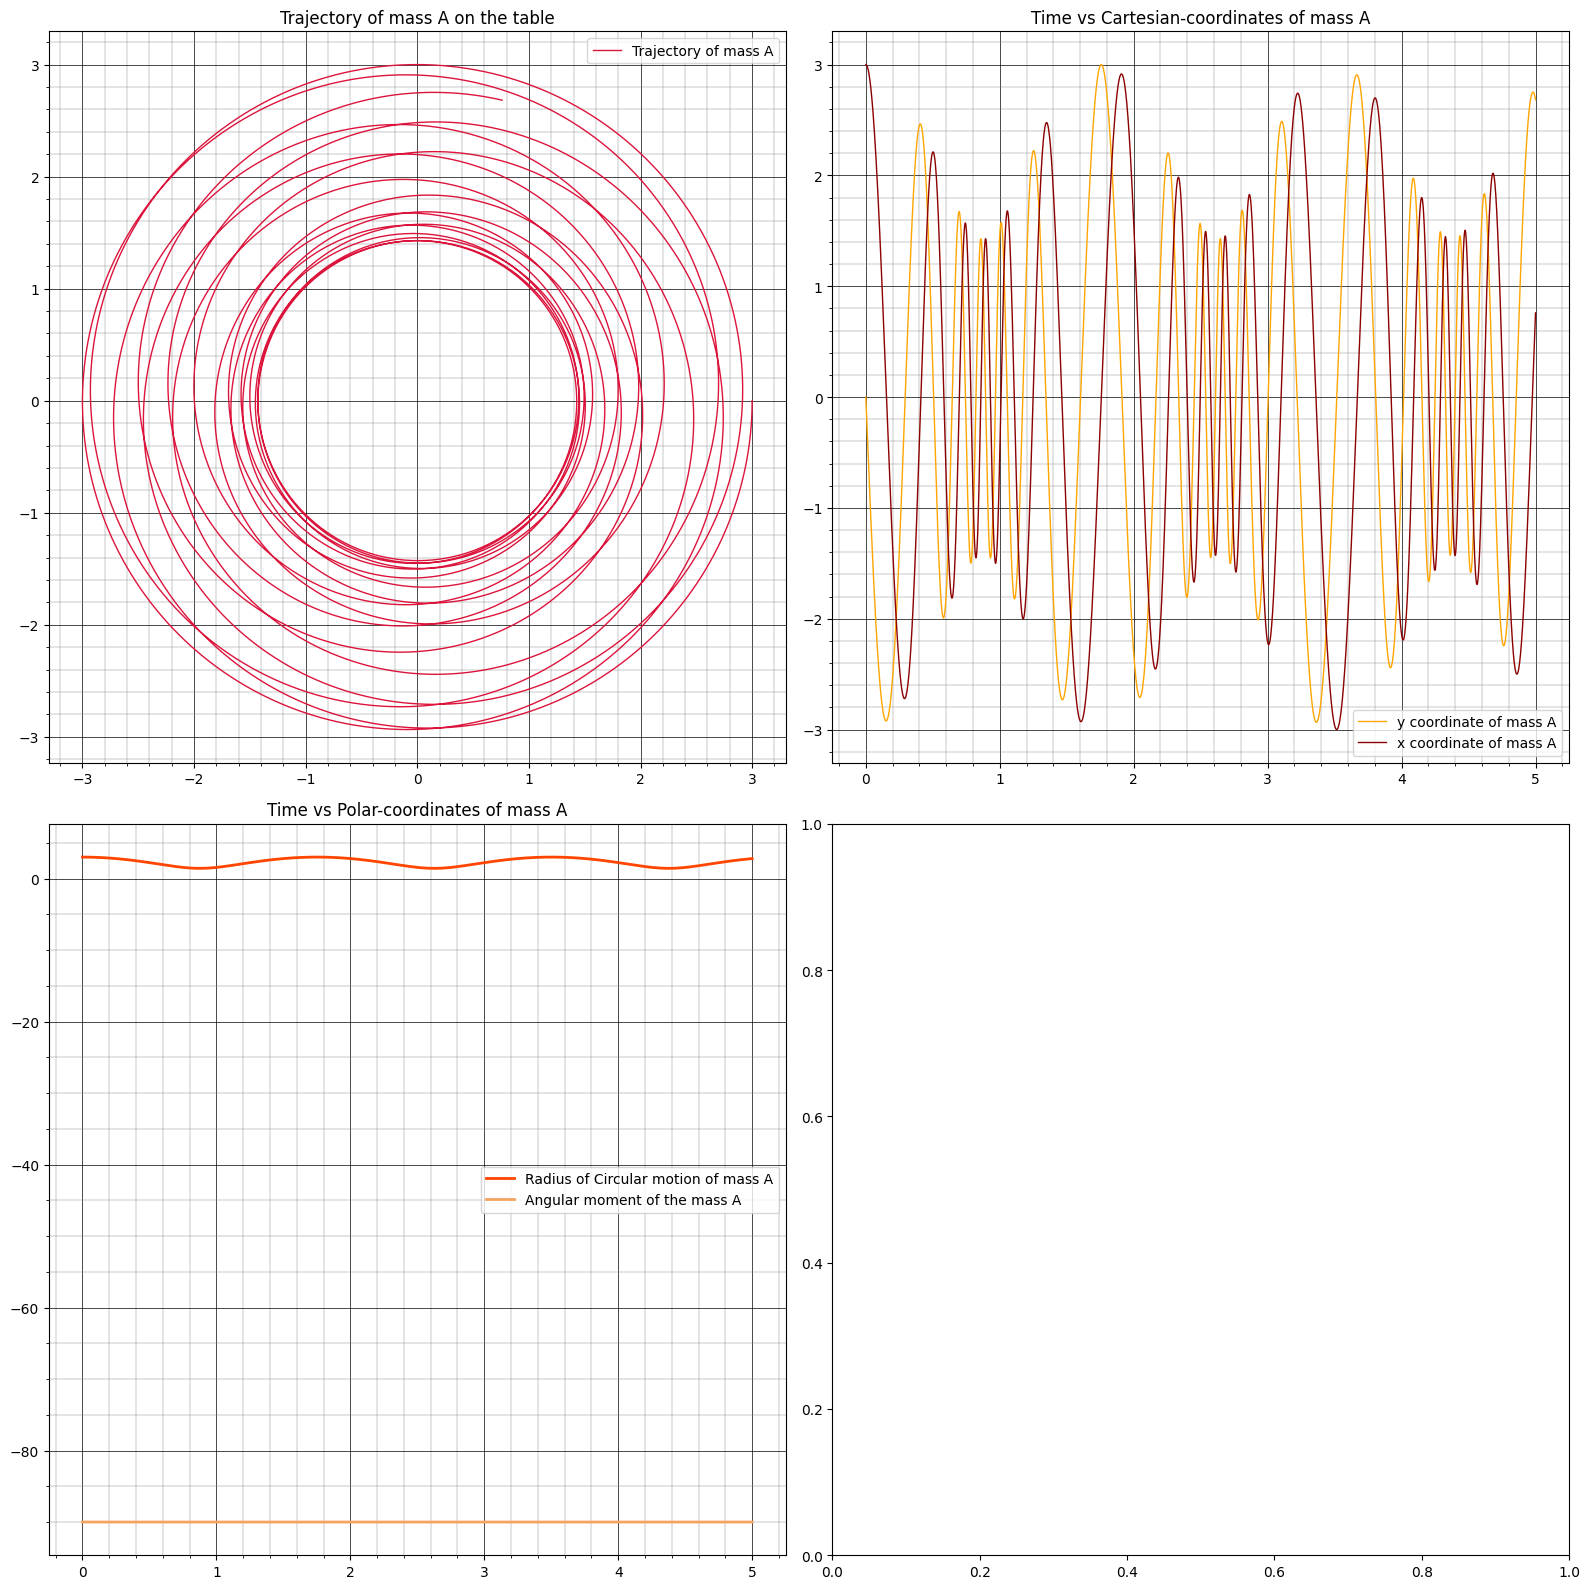

In [ ]:
fig,axes=plt.subplots(2,2,figsize=(16,16))

axes[0,0].plot(sol.T[0]*np.cos(sol.T[1]),sol.T[0]*np.sin(sol.T[1]),color="crimson",linewidth=1,label="Trajectory of mass A")
axes[0,0].minorticks_on()
axes[0,0].grid(which="minor",linewidth=0.3,color="gray")
axes[0,0].grid(which="major",color="black",linewidth=0.5)
axes[0,0].legend()
axes[0,0].set_title("Trajectory of mass A on the table")

axes[0,1].plot(t,sol.T[0]*np.sin(sol.T[1]),color="orange",linewidth=1,label="y coordinate of mass A")
axes[0,1].plot(t,sol.T[0]*np.cos(sol.T[1]),color="darkred",linewidth=1,label="x coordinate of mass A")
axes[0,1].minorticks_on()
axes[0,1].grid(which="minor",linewidth=0.3,color="gray")
axes[0,1].grid(which="major",color="black",linewidth=0.5)
axes[0,1].legend()
axes[0,1].set_title("Time vs Cartesian-coordinates of mass A")

axes[1,0].plot(t,sol.T[0],color="orangered",linewidth=2,label="Radius of Circular motion of mass A")
axes[1,0].plot(t,L,color="sandybrown",linewidth=2,label="Angular moment of the mass A")
axes[1,0].minorticks_on()

axes[1,0].grid(which="minor",linewidth=0.3,color="gray")
axes[1,0].grid(which="major",color="black",linewidth=0.5)
axes[1,0].legend()
axes[1,0].set_title("Time vs Polar-coordinates of mass A")



plt.tight_layout()

### **3. Solving for Angular Velocity $\dot{\theta}$ (Conservation of Angular Momentum)**

From the tangential equation:
$$2\dot{r}\dot{\theta} + r\ddot{\theta} = 0$$
$$\implies 2\frac{1}{r}\frac{dr}{dt}\dot{\theta} + \frac{d\dot{\theta}}{dt} = 0$$

Separating variables to integrate:
$$2\int \frac{1}{r} dr = -\int \frac{1}{\dot{\theta}} d\dot{\theta}$$
$$\implies 2 \ln(r) = -\ln(\dot{\theta}) + \ln(C)$$
$$\implies \ln(r^2) = \ln\left(\frac{C}{\dot{\theta}}\right)$$
$$\implies r^2 = \frac{C}{\dot{\theta}}$$
$$\implies \dot{\theta} = \frac{C}{r^2}$$



### **4. Integrating the Radial Acceleration Equation**

We rewrite $\ddot{r}$ using the chain rule to change the independent variable from $t$ to $r$:
$$\ddot{r} = \frac{d}{dt}\left(\frac{dr}{dt}\right) = \frac{dr}{dt} \frac{d}{dr}\left(\frac{dr}{dt}\right)$$

Substituting $\ddot{r}$ and $\dot{\theta} = \frac{C}{r^2}$ into the radial differential equation:
$$\frac{dr}{dt} \frac{d}{dr}\left(\frac{dr}{dt}\right) = \frac{m_A r \left(\frac{C}{r^2}\right)^2 - m_B g}{m_A + m_B}$$
$$\implies \frac{1}{2} \frac{d}{dr}\left[\left(\frac{dr}{dt}\right)^2\right] = \frac{m_A C^2 r^{-3} - m_B g}{m_A + m_B}$$

Integrating both sides with respect to $r$:
$$\frac{1}{2} \left(\frac{dr}{dt}\right)^2 = \int \left( C_1 r^{-3} - C_2 \right) dr$$

Where $C_1 = \frac{m_A C^2}{m_A + m_B}$ and $C_2 = \frac{m_B g}{m_A + m_B}$.

Performing the integration:
$$\implies \frac{1}{2} \left(\frac{dr}{dt}\right)^2 = \frac{C_1 r^{-2}}{-2} - C_2 r + D$$
$$\implies \left(\frac{dr}{dt}\right)^2 = -C_1 r^{-2} - 2C_2 r + 2D$$

Taking the square root gives the final relation for the radial velocity:
$$\frac{dr}{dt} = \sqrt{-C_1 r^{-2} - 2C_2 r + 2D}$$



### **5. Final Integral Form**

Separating variables one last time yields the integral relation for time $t$:

$$\int \frac{dr}{\sqrt{-C_1 r^{-2} - 2C_2 r + 2D}} = \int dt$$

### Conical pendulum